# **Mandatory Pratcial Work 01 : CNNs on iCoSimal V3 dataset**


 __________________________________________________

### **SUMMARY**
**Dataset**

**I.CNN**
- Simple CNN
- Deeper CNN
- A more deeper cnn
- Adding dropout

**II. Importance of hyperparameter tuning**
- 1. Tuning the size of the filters : 16, 32, 64
- 2. Tuning hte size of the kernel of the convolutionnal layers : 3, 5, 7
- 3. Tuning the size of the kernel of maxpooling : 2, 3
- 4. Tuning the learning rate : 0.1, 0.01, 0.001, 0.0001
- 5. Tuning the nbatch : 16, 32, 64
- 6. Tuning the nepochs : 10, 20

**III. Overfitting and underfitting**

**IV. Regularization**
- 1. Dropout
- 2. Early stopping

**V. Optimisation**
- 1. Adam
- 2. RMSprop

**VI. Optinal objectives**
- 1. Wandb
- 2. Data augmentation
- 3. ResNet and GoogleNet

**Conclusion**
________________________________________________

In [ ]:
#---gpu
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 2080 with Max-Q Design


In [ ]:
#import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Dataset**

 To perform quicker experimentations, the images of the dataset **iCoSimal V3** will be resized 64x64. The dataset will be load and split into the training data set and the validation data set.

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

data_root = "icosimal_img_class_03/data_uniform_224_224_sets"

train_data = datasets.ImageFolder(
    root=f"{data_root}/train",
    transform=train_transforms
)

val_data = datasets.ImageFolder(
    root=f"{data_root}/validate",
    transform=val_transforms
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

print(f"Classes        : {train_data.classes}")
print(f"Nb classes     : {len(train_data.classes)}")
print(f"Train samples  : {len(train_data)}")
print(f"Val samples    : {len(val_data)}")

images, labels = next(iter(train_loader))
print(f"Shape du batch : {images.shape}")   # [32, 3, 224, 224]


Classes        : ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Nb classes     : 10
Train samples  : 24000
Val samples    : 6000
Shape du batch : torch.Size([32, 3, 64, 64])


We can display some examples of each class :

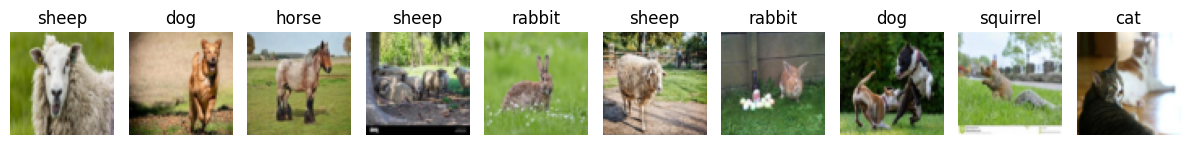

In [ ]:
figure = plt.figure(figsize=(12, 12))
for i in range(10):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(1, 10, 1+i)
    plt.title(train_data.classes[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))     # (C,H,W) -> (H,W,C)

plt.tight_layout()
plt.show()

### **I. Simple CNN**

We will start from a simple CNN architectures and increase its complexity to show the benefit of depth. The model will have :
- One convolutional network with a kernel size of 5 as shown in class of week 4,
- a ReLU activation,
- a max pooling ooling layer and a stride of 2 to preserve the dimension structure,
- a flatten layer,
- a linear layer.


In [ ]:
def simple_cnn(units=[3*64*64, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1',    torch.nn.Conv2d(3, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('relu_2',    torch.nn.ReLU())
    model.add_module('maxpool_3', torch.nn.MaxPool2d(kernel_size=2, stride=2))
    model.add_module('flatten_4', torch.nn.Flatten())
    model.add_module('linear_5',  torch.nn.Linear(32*32*32, units[1]))  # 64x64 -> 32x32 after MaxPool
    return model

We will use the following function train_eval as the training loop to test the model, without any optimizer. The code is reused from the previous weekly practical works. To anticipate the last part of this pratical work, we will use "weight and biases" to monitore the training of our models.

In [ ]:
!pip install wandb
import wandb

In [ ]:
def train_eval(model, lr, nepochs, nbatch, training_data, validation_data, output=True):
    #wandb.init(         # wandb
    #     project = "cnn-training",
    #     mode="online",
    #     config={
    #     "lr": lr,
    #     "nepochs": nepochs,
    #     "batch_size": nbatch
    #})

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU
    model = model.to(device)                                                 # GPU

    cost_hist, cost_hist_test = [], []
    acc_hist,  acc_hist_test  = [], []
    cost_ce = torch.nn.CrossEntropyLoss()

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0

        for batch, (X, Y) in enumerate(training_loader):
            X, Y = X.to(device), Y.to(device)                               # GPU
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            loss.backward()
            with torch.no_grad():
                for param in model.parameters():
                    param -= lr * param.grad
                    param.grad.zero_()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0

        with torch.no_grad():
            for X, Y in test_loader:
                X, Y = X.to(device), Y.to(device)                           # GPU
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test  += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        cost_test /= nbatches_test
        acc_test /= size_test

        #wandb.log({
        #     "epoch": epoch,
        #     "train_loss": cost,
        #     "train_accuracy": acc,
        #     "val_loss": cost_test,
        #     "val_accuracy": acc_test,
        #})

        if output:
            print("Epoch %i : %f, %f, %f, %f" % (epoch, cost, acc, cost_test, acc_test))

        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

We can now plot the cost and accuracy for the train and validation test. The number of batchs, epochs and the value of the learning rate are the same the example shown in class during the week 4, as they keep the running time reasonable.

In [ ]:
nbatch = 32
nepochs = 10
lr = 0.001

Epoch 0 : 2.236573, 0.170167, 2.193918, 0.198333
Epoch 1 : 2.155374, 0.226333, 2.138729, 0.227167
Epoch 2 : 2.107288, 0.259708, 2.096677, 0.247833
Epoch 3 : 2.071907, 0.273792, 2.069720, 0.270833
Epoch 4 : 2.044198, 0.291792, 2.045146, 0.283333
Epoch 5 : 2.020602, 0.302667, 2.025527, 0.299000
Epoch 6 : 2.001117, 0.311833, 2.010768, 0.295500
Epoch 7 : 1.982444, 0.321875, 2.001739, 0.307833
Epoch 8 : 1.964689, 0.327792, 1.979335, 0.315667
Epoch 9 : 1.948919, 0.335250, 1.984062, 0.315500


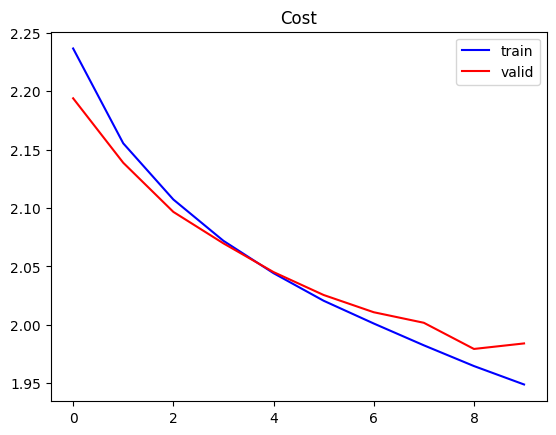

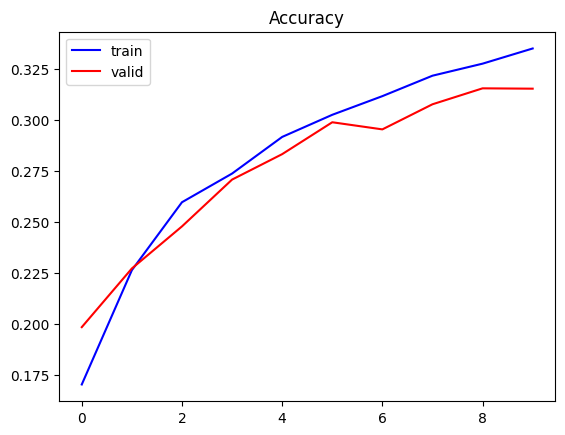

In [ ]:
simple_cnn1 = simple_cnn()

cost_train, cost_valid, acc_train, acc_valid = train_eval(simple_cnn1, lr, nepochs, nbatch, train_data, val_data)

#wandb.finish()

plt.figure(1)
plt.plot(range(len(cost_train)), cost_train, "b-", label='train')
plt.plot(range(len(cost_valid)), cost_valid, "r-", label='valid')
plt.legend()
plt.title("Cost")
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train)), acc_train, "b-", label='train')
plt.plot(range(len(acc_valid)), acc_valid, "r-", label='valid')
plt.legend()
plt.title("Accuracy")
plt.show()

We will create a function to evaluate the test accuracy of each model.

In [ ]:
def evaluate(model, dataset, batch_size=64, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    torch.cuda.empty_cache()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.to(device)
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            preds = model(X)
            correct += (preds.argmax(dim=1) == Y).float().sum().item()
            total += len(Y)

    acc = correct / total
    print(f"Test accuracy: {100 * acc:.1f}%")
    return acc

In [ ]:
acc_test = evaluate(simple_cnn1, val_data)

Test accuracy: 31.6%


We can clearly see with the value of the accuracy on the validation dataset and the curves of the cost and accuracy that the model ```simple_cnn``` is far to simple to learn those complex images. However, there is no overfitting : the curves are close.

We will increase the complexity of the model by adding layers.

#### **Deeper CNN**
The model will have more layer to increase its efficiency :
- One convolutional network with a kernel size of 3 as shown in class of week 4,
- a ReLU activation,
- a max pooling ooling layer and a stride of 2 to preserve the dimension structure,
- a flatten layer,
- a linear layer.

In [ ]:
def deeper_cnn(units=[3*64*64, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1',    torch.nn.Conv2d(3, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(32))
    model.add_module('relu_1',    torch.nn.ReLU())
    model.add_module('maxpool_1', torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 64 -> 32

    model.add_module('conv_2',    torch.nn.Conv2d(32, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(32))
    model.add_module('relu_2',    torch.nn.ReLU())
    model.add_module('maxpool_2', torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 32 -> 16

    model.add_module('flatten',   torch.nn.Flatten())
    model.add_module('linear',    torch.nn.Linear(16*16*32, units[1]))  # 16x16x32
    return model

Epoch 0 : 1.951407, 0.313250, 1.782611, 0.390500
Epoch 1 : 1.677311, 0.421833, 1.692846, 0.416500
Epoch 2 : 1.555694, 0.466083, 1.588857, 0.459167
Epoch 3 : 1.458726, 0.504792, 2.002343, 0.363167
Epoch 4 : 1.393965, 0.529500, 1.838601, 0.394167
Epoch 5 : 1.338245, 0.547667, 1.533759, 0.469667
Epoch 6 : 1.289730, 0.566875, 1.472110, 0.493833
Epoch 7 : 1.248386, 0.581208, 1.482530, 0.481333
Epoch 8 : 1.210423, 0.594375, 1.436586, 0.502667
Epoch 9 : 1.173630, 0.610333, 1.533469, 0.481333


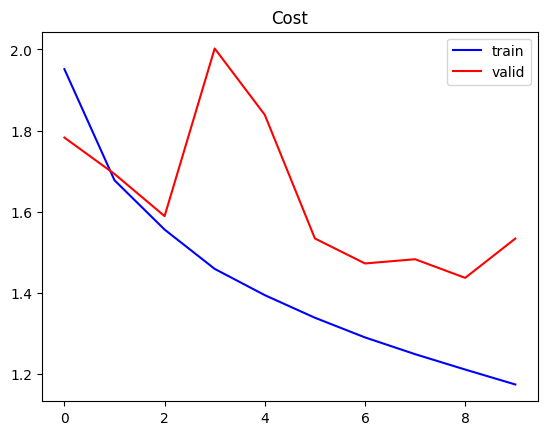

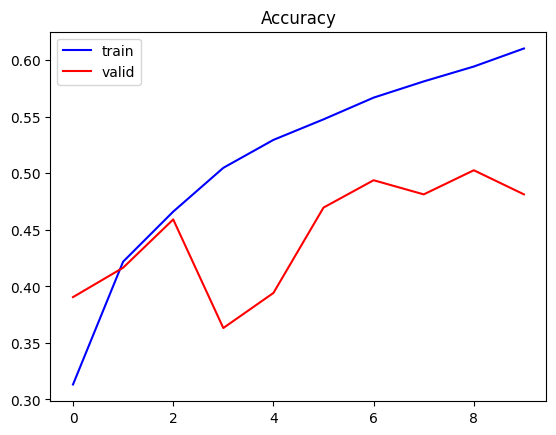

In [ ]:
deeper_cnn = deeper_cnn()

cost_train2, cost_valid2, acc_train2, acc_valid2 = train_eval(deeper_cnn, lr, nepochs, nbatch, train_data, val_data)

#wandb.finish()

plt.figure(1)
plt.plot(range(len(cost_train2)), cost_train2, "b-", label='train')
plt.plot(range(len(cost_valid2)), cost_valid2, "r-", label='valid')
plt.legend()
plt.title("Cost")
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train2)), acc_train2, "b-", label='train')
plt.plot(range(len(acc_valid2)), acc_valid2, "r-", label='valid')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
acc_test2 = evaluate(deeper_cnn, val_data)

Test accuracy: 48.1%


We can see that the accuracy has increase. That's the benefit of the depth. We can create a more deeper cnn.

#### **A more deeper CNN**
The model will have more layer to increase its efficiency :
- 3 convolutional network layers with a kernel size of 3 as shown in class of week 4,
- 3 ReLU activation,
- 3 max pooling ooling layers and a stride of 2 to preserve the dimension structure,
- a flatten layer,
- a linear layer.

In [ ]:
def more_deeper_cnn(units=[3*64*64, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1',      torch.nn.Conv2d(3, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(32))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 64 -> 32

    model.add_module('conv_2',      torch.nn.Conv2d(32, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(32))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 32 -> 16

    model.add_module('conv_3',      torch.nn.Conv2d(32, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(32))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 16 -> 8

    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('linear',      torch.nn.Linear(8*8*32, units[1]))  # 8x8x32

    return model

Epoch 0 : 2.026850, 0.284000, 1.841093, 0.368000
Epoch 1 : 1.740532, 0.404625, 1.678980, 0.419833
Epoch 2 : 1.615169, 0.452583, 1.606122, 0.447833
Epoch 3 : 1.529167, 0.478333, 1.586838, 0.446500
Epoch 4 : 1.464875, 0.503583, 1.653477, 0.423500
Epoch 5 : 1.415706, 0.520292, 1.459959, 0.498167
Epoch 6 : 1.375721, 0.537083, 1.591876, 0.459000
Epoch 7 : 1.337820, 0.548542, 1.603681, 0.459500
Epoch 8 : 1.302101, 0.562083, 1.922863, 0.375000
Epoch 9 : 1.277762, 0.569167, 1.336669, 0.549833


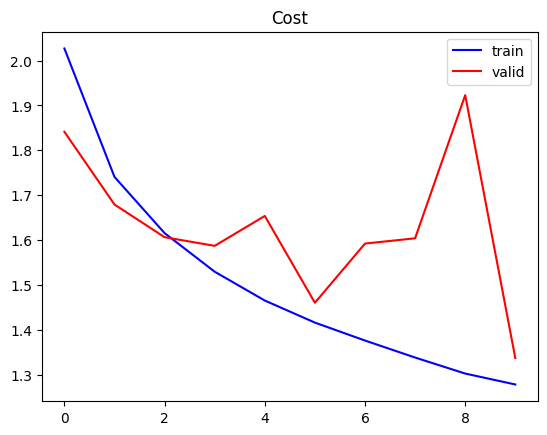

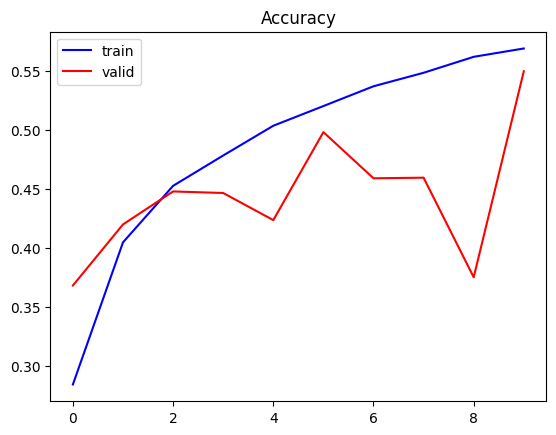

In [ ]:
more_deeper_cnn = more_deeper_cnn()

cost_train3, cost_valid3, acc_train3, acc_valid3 = train_eval(more_deeper_cnn, lr, nepochs, nbatch, train_data, val_data)
#wandb.finish()

plt.figure(1)
plt.plot(range(len(cost_train3)), cost_train3, "b-", label='train')
plt.plot(range(len(cost_valid3)), cost_valid3, "r-", label='valid')
plt.legend()
plt.title("Cost")
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train3)), acc_train3, "b-", label='train')
plt.plot(range(len(acc_valid3)), acc_valid3, "r-", label='valid')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
acc_test3 = evaluate(more_deeper_cnn, val_data)

Test accuracy: 55.0%


#### **Adding dropout**
On the previous cruves, we can see that the red curve is very instable, even if the accuracy is good. Futhermore, the final train and val accuracy aren't similar. There is a little overfitting. To minimize this behavior, we can add some ```dropout```. We begin with 30% of dropout.

In [ ]:
def more_deeper_cnn_dropout(units=[3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(32))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 64 -> 32

    model.add_module('conv_2',      torch.nn.Conv2d(32, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(32))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 32 -> 16

    model.add_module('conv_3',      torch.nn.Conv2d(32, 32, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(32))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))  # 16 -> 8


    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.3))  # dropout at 30%
    model.add_module('linear',      torch.nn.Linear(8*8*32, units[1]))

    return model

Epoch 0 : 2.110335, 0.242042, 1.865423, 0.363333
Epoch 1 : 1.829380, 0.365750, 1.712502, 0.411833
Epoch 2 : 1.689241, 0.412875, 1.624341, 0.441833
Epoch 3 : 1.592765, 0.450958, 1.548611, 0.469833
Epoch 4 : 1.530060, 0.476292, 1.481302, 0.492500
Epoch 5 : 1.484559, 0.489875, 1.501323, 0.489500
Epoch 6 : 1.445528, 0.503458, 1.466272, 0.490167
Epoch 7 : 1.409865, 0.513125, 1.465874, 0.491333
Epoch 8 : 1.387741, 0.524125, 1.442994, 0.507500
Epoch 9 : 1.357338, 0.534583, 1.381256, 0.529667


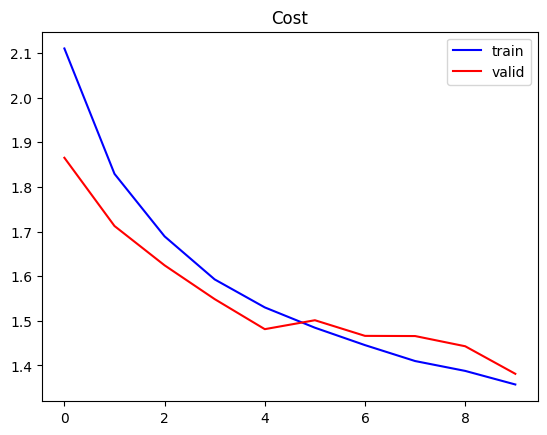

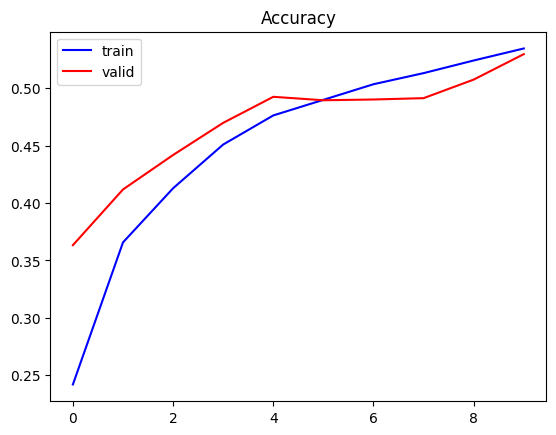

In [ ]:
more_deeper_cnn_dropout = more_deeper_cnn_dropout()

cost_train4, cost_valid4, acc_train4, acc_valid4 = train_eval(more_deeper_cnn_dropout, lr, nepochs, nbatch, train_data, val_data)
#wandb.finish()

plt.figure(1)
plt.plot(range(len(cost_train4)), cost_train4, "b-", label='train')
plt.plot(range(len(cost_valid4)), cost_valid4, "r-", label='valid')
plt.legend()
plt.title("Cost")
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train4)), acc_train4, "b-", label='train')
plt.plot(range(len(acc_valid4)), acc_valid4, "r-", label='valid')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
acc_test4 = evaluate(more_deeper_cnn_dropout, val_data)

Test accuracy: 53.0%


The train and validation curves are much more stable with a dropout. However, the accuracy has decrease. This is the trade-off between the accuracy and the stablisation of the model. This is probably due to the number of ```epochs``` that is very low. This tunning will be studied in the next part.

#### ***Conclusion***

We have seen on this part that adding layer (convolution, pooling...) to our model enables it to be more efficient. Indeed, deep networks are more efficient and generalise better : that's the benefit of the depth. Our best model is ```more_deeper_cnn_dropout```, with an accuracy of **48.1%** when wandb was used, and **53%** without. We will keep this last value as our reference. Indeed, wandb was used for this first part and not for the other ones.
________________

### **II. Importance of the hyperparameter tuning**

We have to tune different types of hyperparameters : the hyperparameters of the training loop (lr, nbatch, nepoch) and the hyperparameters of the model (number of filter in the convolutional layer, the size of the kernel and the size of the max pooling). We will focus firstly on tunning the hyperparameter of the model. The ```nbatch``` , the ```learning rate``` and the ```nepochs``` will be :


In [ ]:
nbatch = 32
nepochs = 10
lr = 0.001

After the tunning of the hyperparameter of the model, we will tune the ```learning rate```, the ```nbatch``` and the ```nepochs``` on the most efficient model.

The parmeters ```stride``` and ```padding``` will stay the same to preserve the spatiale structure of the image.

We will use the model of the deeper cnn with the dropout as the base of this part.


#### **1. Tuning the size of the filters**
##### **a. 16**

In [ ]:
def deeper_cnnfilter16(units = [3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 16, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(16))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_2',      torch.nn.Conv2d(16, 16, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(16))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_3',      torch.nn.Conv2d(16, 16, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(16))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.3))  # dropout at 30%
    model.add_module('linear',      torch.nn.Linear(8*8*16, units[1]))

    return model

In [ ]:
deeper_cnnfilter16 = deeper_cnnfilter16()

cost_train5, cost_valid5, acc_train5, acc_valid5 = train_eval(deeper_cnnfilter16, lr, nepochs, nbatch, train_data, val_data)

Epoch 0 : 2.218518, 0.198292, 1.997539, 0.301500
Epoch 1 : 1.959136, 0.308958, 1.838761, 0.363167
Epoch 2 : 1.833501, 0.360667, 1.746689, 0.393500
Epoch 3 : 1.749766, 0.394458, 1.707475, 0.407167
Epoch 4 : 1.685066, 0.412833, 1.675964, 0.421833
Epoch 5 : 1.634580, 0.433292, 1.662051, 0.426333
Epoch 6 : 1.598273, 0.449792, 1.647577, 0.426667
Epoch 7 : 1.570108, 0.457833, 1.638820, 0.435500
Epoch 8 : 1.540989, 0.466417, 1.537272, 0.475167
Epoch 9 : 1.519968, 0.478625, 1.550341, 0.468500


In [ ]:
acc_test5 = evaluate(deeper_cnnfilter16, val_data)

Test accuracy: 46.9%


##### **b.32**

This size has already been tested in the previous part with the model ```more_deeper_cnn_dropout```, with an accuracy of **53%**.



##### **c. 64**

In [ ]:
def deeper_cnnfilter64(units = [3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(64))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_2',      torch.nn.Conv2d(64, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(64))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_3',      torch.nn.Conv2d(64, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(64))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.3))  # dropout at 30%
    model.add_module('linear',      torch.nn.Linear(8*8*64, units[1]))
    return model

In [ ]:
deeper_cnnfilter64 = deeper_cnnfilter64()

cost_train6, cost_valid6, acc_train6, acc_valid6 = train_eval(deeper_cnnfilter64, lr, nepochs, nbatch, train_data, val_data)

Epoch 0 : 1.994409, 0.297958, 1.728859, 0.408167
Epoch 1 : 1.692484, 0.415708, 1.588168, 0.462000
Epoch 2 : 1.561125, 0.462083, 1.512745, 0.484000
Epoch 3 : 1.471594, 0.491542, 1.450335, 0.504667
Epoch 4 : 1.410451, 0.514625, 1.451223, 0.496000
Epoch 5 : 1.363553, 0.532375, 1.558009, 0.471500
Epoch 6 : 1.312180, 0.553417, 1.412347, 0.510167
Epoch 7 : 1.271566, 0.562583, 1.308866, 0.553833
Epoch 8 : 1.240252, 0.578458, 1.374760, 0.529833
Epoch 9 : 1.215309, 0.586917, 1.277443, 0.565667


In [ ]:
acc_test6 = evaluate(deeper_cnnfilter64, val_data)

Test accuracy: 56.6%


The better model is the one with **a filter size of 64** with an accuracy of **56.6%**. We will keep this model and adapt its kernel size with the following values : 3, 5, 7.

#### **2. Tuning the size of the kernel of the convolutionnal layers**
##### **a. 3**
This model corresponds to ```deeper_cnnfilter64```, and has an accuracy of **56.6%** with **kernel_size = 3**.

##### **b.5**

In [ ]:
def deeper_cnnkernel5(units = [3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 64, kernel_size=5, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(64))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_2',      torch.nn.Conv2d(64, 64, kernel_size=5, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(64))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_3',      torch.nn.Conv2d(64, 64, kernel_size=5, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(64))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.3))  # dropout at 30%
    model.add_module('linear',      torch.nn.Linear(8*8*64, units[1]))

    return model

In [ ]:
deeper_cnnkernel5 = deeper_cnnkernel5()

cost_train7, cost_valid7, acc_train7, acc_valid7 = train_eval(deeper_cnnkernel5, lr, nepochs, nbatch, train_data, val_data)

Epoch 0 : 1.990561, 0.294833, 1.733014, 0.408000
Epoch 1 : 1.684124, 0.416250, 1.575271, 0.458667
Epoch 2 : 1.549767, 0.461042, 1.488794, 0.487500
Epoch 3 : 1.455700, 0.495958, 1.552656, 0.466500
Epoch 4 : 1.391763, 0.518333, 1.539475, 0.476333
Epoch 5 : 1.326372, 0.544792, 1.408618, 0.513500
Epoch 6 : 1.283282, 0.562292, 1.400387, 0.514000
Epoch 7 : 1.237904, 0.577667, 1.347491, 0.534167
Epoch 8 : 1.201073, 0.591542, 1.324188, 0.543833
Epoch 9 : 1.171496, 0.595833, 1.298732, 0.549000


In [ ]:
acc_test7 = evaluate(deeper_cnnkernel5, val_data)

Test accuracy: 54.9%


##### **c.7**

In [ ]:
def deeper_cnnkernel7(units = [3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 64, kernel_size=7, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(64))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_2',      torch.nn.Conv2d(64, 64, kernel_size=7, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(64))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_3',      torch.nn.Conv2d(64, 64, kernel_size=7, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(64))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.3))  # dropout at 30%
    model.add_module('linear',      torch.nn.Linear(8*8*64, units[1]))
    return model

In [ ]:
deeper_cnnkernel7 = deeper_cnnkernel7()

cost_train8, cost_valid8, acc_train8, acc_valid8 = train_eval(deeper_cnnkernel7, lr, nepochs, nbatch, train_data, val_data)

Epoch 0 : 1.981953, 0.293750, 1.735825, 0.401667
Epoch 1 : 1.680345, 0.415042, 1.580819, 0.446333
Epoch 2 : 1.547053, 0.461750, 1.522291, 0.472833
Epoch 3 : 1.453939, 0.497583, 1.513771, 0.475833
Epoch 4 : 1.384317, 0.522375, 1.660185, 0.433833
Epoch 5 : 1.323232, 0.546250, 1.571408, 0.462833
Epoch 6 : 1.274848, 0.561625, 1.380099, 0.520333
Epoch 7 : 1.225866, 0.581875, 1.560191, 0.466167
Epoch 8 : 1.184548, 0.596250, 1.603198, 0.468667
Epoch 9 : 1.141463, 0.607333, 1.483690, 0.500333


In [ ]:
acc_test8 = evaluate(deeper_cnnkernel7, val_data)

Test accuracy: 50.0%


The best kernel size seems to be : **3** with an accuracy of **56.6%**. This refers to the model ```deeper_cnnfilter64```.

#### **3. Tuning the size of the kernel of maxpooling**
We will test the kernel size of the maxpool layer with the values 2 and 3.

##### **a. 2**
This model is the best previous one (````deeper_cnnfilter64````)with an accuracy of **56.6%** and a kernel size for the maxpooling of 2.



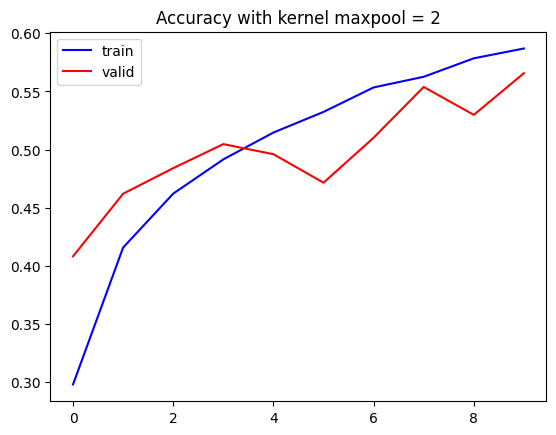

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train6)), acc_train6, "b-", label='train')
plt.plot(range(len(acc_valid6)), acc_valid6, "r-", label='valid')
plt.legend()
plt.title("Accuracy with kernel maxpool = 2")
plt.show()

##### **b.3**

In [ ]:
def deeper_cnnmaxpool3(units=[3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(64))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=3, stride=2))

    model.add_module('conv_2',      torch.nn.Conv2d(64, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(64))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=3, stride=2))

    model.add_module('conv_3',      torch.nn.Conv2d(64, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(64))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=3, stride=2))


    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.3))  # dropout at 30%
    model.add_module('linear',      torch.nn.Linear(7*7*64, units[1]))

    return model

In [ ]:
deeper_cnnmaxpool3 = deeper_cnnmaxpool3()

cost_train9, cost_valid9, acc_train9, acc_valid9 = train_eval(deeper_cnnmaxpool3, lr, nepochs, nbatch, train_data, val_data)

Epoch 0 : 1.961746, 0.311625, 1.656470, 0.434833
Epoch 1 : 1.618987, 0.439208, 1.518060, 0.480333
Epoch 2 : 1.493631, 0.486292, 1.425601, 0.513167
Epoch 3 : 1.413729, 0.515583, 1.366380, 0.530667
Epoch 4 : 1.351953, 0.536500, 1.312056, 0.553000
Epoch 5 : 1.308275, 0.554458, 1.282224, 0.567167
Epoch 6 : 1.264645, 0.567750, 1.295872, 0.558000
Epoch 7 : 1.226343, 0.580208, 1.394733, 0.529833
Epoch 8 : 1.197810, 0.592500, 1.331907, 0.544667
Epoch 9 : 1.174422, 0.601333, 1.308836, 0.552500


In [ ]:
acc_test9 = evaluate(deeper_cnnmaxpool3, val_data)

Test accuracy: 55.2%


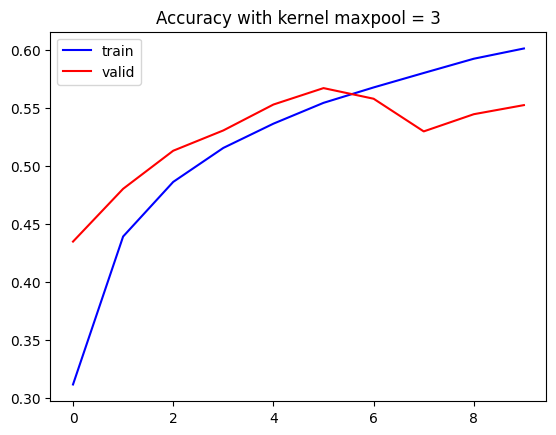

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train9)), acc_train9, "b-", label='train')
plt.plot(range(len(acc_valid9)), acc_valid9, "r-", label='valid')
plt.legend()
plt.title("Accuracy with kernel maxpool = 3")
plt.show()

We have tunned the hyperparameters of the model and found an efficient model : the one with **a kernel for the maxpool layer of size 2**, with an accuracy of **56.6%**. The best model after this tuning is ```deeper_cnnfilter64```. We can justify this choice also by highlighting the signs of an overfitting with a kernel of maxpooling of size 3. We prefered keeping a model without overfitting.

We will now tune the hyperparameter of the training : ```learning rate```, the ```nbatch``` and the ```nepochs``` on ```best_model``` .


#### **4. Tuning the learning rate**
We will test the values of 0.1, 0.01, 0.001 and 0.0001 for the learning rate.

In [ ]:
lr = 0.1
best_model = deeper_cnnfilter64()
cost_train10, cost_valid10, acc_train10, acc_valid10 = train_eval(best_model, lr, nepochs, nbatch, train_data, val_data)
acc_test10 = evaluate(best_model, val_data)

Epoch 0 : 2.173380, 0.296542, 1.720180, 0.391167
Epoch 1 : 1.618173, 0.437750, 1.716913, 0.389833
Epoch 2 : 1.453223, 0.499667, 1.684670, 0.443667
Epoch 3 : 1.352819, 0.535417, 1.434741, 0.499000
Epoch 4 : 1.269430, 0.561458, 1.374807, 0.533167
Epoch 5 : 1.206332, 0.584625, 1.296212, 0.560333
Epoch 6 : 1.150673, 0.603833, 1.336506, 0.538667
Epoch 7 : 1.085112, 0.626958, 1.439488, 0.515833
Epoch 8 : 1.037964, 0.644667, 1.268161, 0.566000
Epoch 9 : 0.996118, 0.658542, 1.275397, 0.566667
Test accuracy: 56.7%


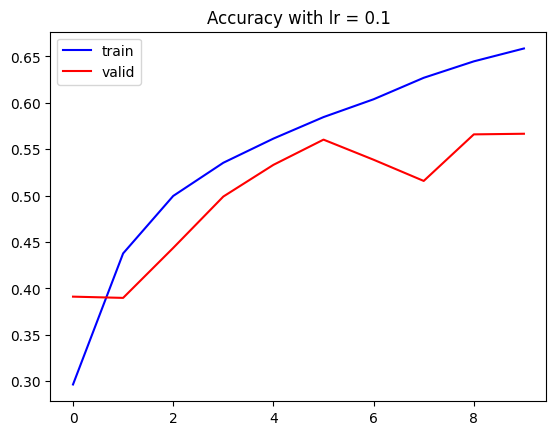

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train10)), acc_train10, "b-", label='train')
plt.plot(range(len(acc_valid10)), acc_valid10, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.1")
plt.show()

In [ ]:
lr = 0.01
best_model = deeper_cnnfilter64()
cost_train11, cost_valid11, acc_train11, acc_valid11 = train_eval(best_model, lr, nepochs, nbatch, train_data, val_data)
acc_test11 = evaluate(best_model, val_data)

Epoch 0 : 1.964152, 0.346083, 1.641040, 0.428833
Epoch 1 : 1.564201, 0.460208, 1.667227, 0.432667
Epoch 2 : 1.422882, 0.509833, 1.548381, 0.466000
Epoch 3 : 1.325682, 0.541625, 1.498645, 0.472333
Epoch 4 : 1.231737, 0.581667, 1.253531, 0.564500
Epoch 5 : 1.166551, 0.602208, 1.262068, 0.563667
Epoch 6 : 1.110073, 0.620875, 1.333551, 0.547667
Epoch 7 : 1.066385, 0.635292, 1.313345, 0.558167
Epoch 8 : 1.023824, 0.649458, 1.357109, 0.554833
Epoch 9 : 0.981216, 0.666167, 1.110879, 0.619500
Test accuracy: 62.0%


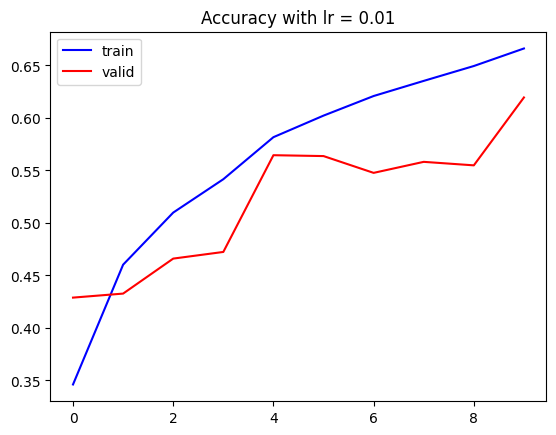

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train11)), acc_train11, "b-", label='train')
plt.plot(range(len(acc_valid11)), acc_valid11, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.01")
plt.show()

With lr = 0.001, this test corresponds to the one conducted in the previous part, with an accuracy of **56.6**, for ```deeper_cnnfilter64```.

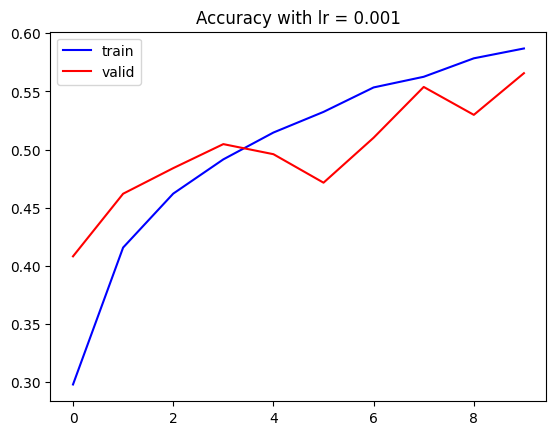

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train6)), acc_train6, "b-", label='train')
plt.plot(range(len(acc_valid6)), acc_valid6, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.001")
plt.show()

In [ ]:
lr = 0.0001
best_model = deeper_cnnfilter64()
cost_train12, cost_valid12, acc_train12, acc_valid12 = train_eval(best_model, lr, nepochs, nbatch, train_data, val_data)
acc_test10 = evaluate(best_model, val_data)

Epoch 0 : 2.322779, 0.148000, 2.150524, 0.228833
Epoch 1 : 2.147677, 0.225083, 2.032441, 0.290333
Epoch 2 : 2.051376, 0.271042, 1.958896, 0.327000
Epoch 3 : 1.980088, 0.306583, 1.904520, 0.344167
Epoch 4 : 1.928119, 0.323375, 1.860155, 0.362833
Epoch 5 : 1.883907, 0.341542, 1.824598, 0.373833
Epoch 6 : 1.847508, 0.354958, 1.789564, 0.387500
Epoch 7 : 1.815266, 0.368542, 1.765082, 0.390667
Epoch 8 : 1.783656, 0.380958, 1.739330, 0.402667
Epoch 9 : 1.754131, 0.393208, 1.715317, 0.413000
Test accuracy: 41.3%


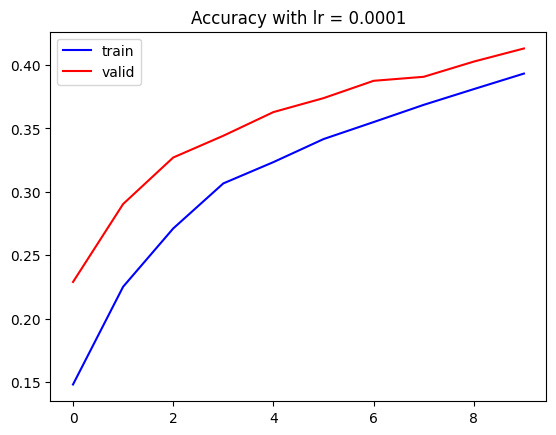

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train12)), acc_train12, "b-", label='train')
plt.plot(range(len(acc_valid12)), acc_valid12, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.0001")
plt.show()

The best learning rate is **0.01**. Indeed, this learning rate implies the highest accuracy, even if there is a instability. The new accuracy of reference is **62%**.

#### **5. Tuning the nbatch**

We will test the following values for ```nbatch``` : 16, 32 and 64.

In [ ]:
nbatch = 16
best_model = deeper_cnnfilter64()
cost_train13, cost_valid13, acc_train13, acc_valid13 = train_eval(best_model, 0.01, nepochs, nbatch, train_data, val_data)
acc_test13 = evaluate(best_model, val_data)

Epoch 0 : 1.970110, 0.343083, 1.637192, 0.432000
Epoch 1 : 1.520022, 0.474208, 1.441673, 0.499833
Epoch 2 : 1.364533, 0.530208, 1.575007, 0.480667
Epoch 3 : 1.260845, 0.566833, 1.390229, 0.526333
Epoch 4 : 1.182133, 0.593500, 1.404454, 0.531500
Epoch 5 : 1.113242, 0.618583, 1.238978, 0.570333
Epoch 6 : 1.053298, 0.640667, 1.228363, 0.576333
Epoch 7 : 1.001846, 0.655000, 1.167273, 0.595500
Epoch 8 : 0.963881, 0.669375, 1.139167, 0.609500
Epoch 9 : 0.918913, 0.686333, 1.103827, 0.625333
Test accuracy: 62.5%


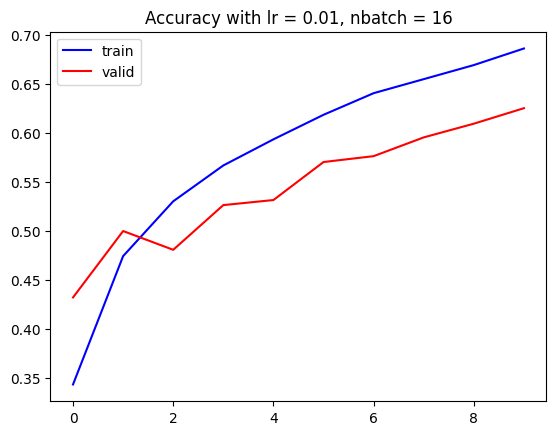

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train13)), acc_train13, "b-", label='train')
plt.plot(range(len(acc_valid13)), acc_valid13, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.01, nbatch = 16")
plt.show()

With nbatch = 32, this test corresponds to the one conducted previously, with an accuracy of **62%**.

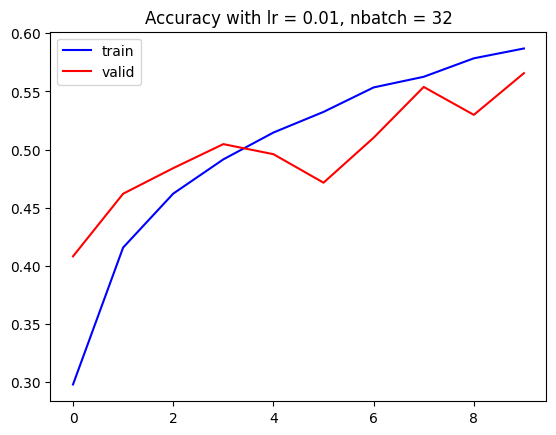

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train11)), acc_train11, "b-", label='train')
plt.plot(range(len(acc_valid11)), acc_valid11, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.01, nbatch = 32")
plt.show()

In [ ]:
nbatch = 64
best_model = deeper_cnnfilter64()
cost_train14, cost_valid14, acc_train14, acc_valid14 = train_eval(best_model, 0.01, nepochs, nbatch, train_data, val_data)
acc_test14 = evaluate(best_model, val_data)

Epoch 0 : 1.974955, 0.334667, 1.766517, 0.386167
Epoch 1 : 1.561854, 0.460542, 1.539661, 0.482500
Epoch 2 : 1.426558, 0.507583, 1.596333, 0.446000
Epoch 3 : 1.332456, 0.540792, 1.964815, 0.389333
Epoch 4 : 1.266793, 0.565417, 1.476228, 0.505000
Epoch 5 : 1.213858, 0.583042, 1.528372, 0.458667
Epoch 6 : 1.166094, 0.600958, 1.500059, 0.513333
Epoch 7 : 1.120008, 0.615625, 1.422906, 0.528833
Epoch 8 : 1.079016, 0.632125, 1.429578, 0.533333
Epoch 9 : 1.049810, 0.640083, 1.684192, 0.484833
Test accuracy: 48.5%


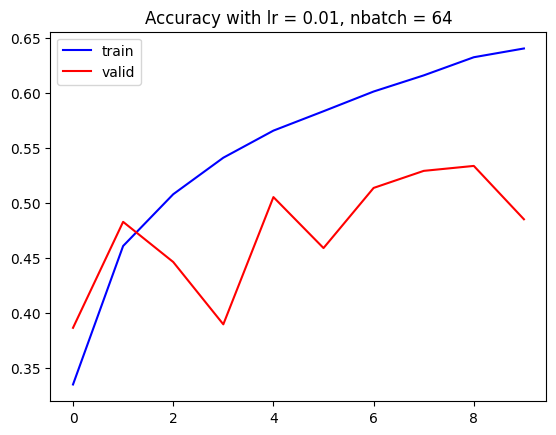

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train14)), acc_train14, "b-", label='train')
plt.plot(range(len(acc_valid14)), acc_valid14, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.01, nbatch = 64")
plt.show()

The best nbatch is **16** because its accuracy is the highest one and there is no signs of overfitting, and we can that the learning process is stable at the end. Futhermore, with nbatch = 32, the validation is stagnating, probably a sign of overfitting. The new accuracy of reference is **62.5%**.

#### **6. Tuning the nepochs**
We will try the values 10, 20 and 50 for the nepochs.

With nepoch = 10, this test corresponds to the one conducted in the previous part, with an accuracy of **62.5**.

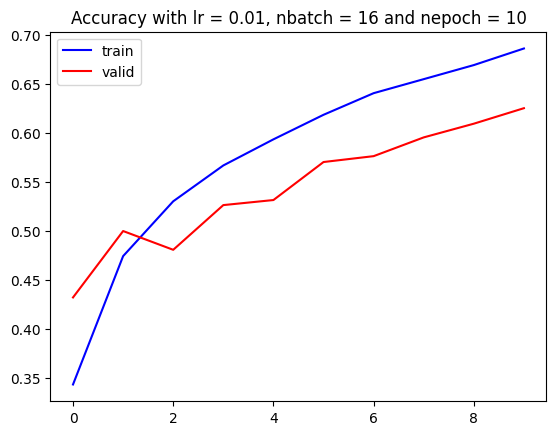

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train13)), acc_train13, "b-", label='train')
plt.plot(range(len(acc_valid13)), acc_valid13, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.01, nbatch = 16 and nepoch = 10")
plt.show()

In [ ]:
nepochs = 20
best_model = deeper_cnnfilter64()
cost_train15, cost_valid15, acc_train15, acc_valid15 = train_eval(best_model, 0.01, nepochs, 16, train_data, val_data)
acc_test15 = evaluate(best_model, val_data)

Epoch 0 : 1.948762, 0.353458, 2.656316, 0.264667
Epoch 1 : 1.534851, 0.468750, 1.481222, 0.488333
Epoch 2 : 1.374261, 0.524917, 1.366170, 0.527333
Epoch 3 : 1.274382, 0.564333, 1.433618, 0.517333
Epoch 4 : 1.193962, 0.591875, 1.264408, 0.564333
Epoch 5 : 1.129251, 0.612250, 1.729186, 0.475500
Epoch 6 : 1.073507, 0.633958, 1.326487, 0.567500
Epoch 7 : 1.025622, 0.648542, 1.578968, 0.504333
Epoch 8 : 0.980622, 0.663833, 1.098092, 0.623667
Epoch 9 : 0.936544, 0.678125, 1.180663, 0.602500
Epoch 10 : 0.911299, 0.689250, 1.190952, 0.600833
Epoch 11 : 0.871589, 0.699125, 1.176008, 0.590333
Epoch 12 : 0.846178, 0.710542, 1.170798, 0.618500
Epoch 13 : 0.812833, 0.722833, 1.208821, 0.598167
Epoch 14 : 0.784584, 0.731458, 1.150092, 0.608833
Epoch 15 : 0.752392, 0.743792, 1.159645, 0.623167
Epoch 16 : 0.730389, 0.752042, 1.048511, 0.650167
Epoch 17 : 0.706062, 0.758250, 1.205016, 0.605500
Epoch 18 : 0.680774, 0.765917, 1.424654, 0.568333
Epoch 19 : 0.663242, 0.771708, 1.129494, 0.617333
Test accur

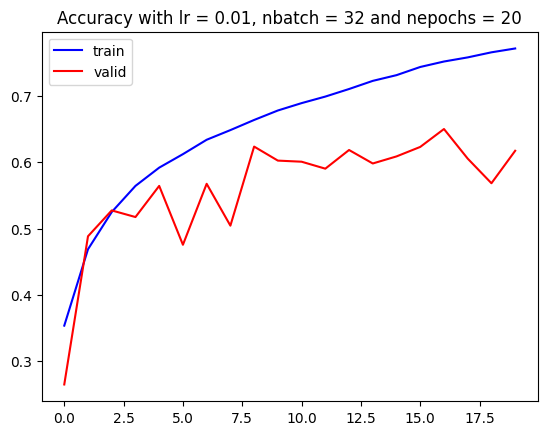

In [ ]:
plt.figure(2)
plt.plot(range(len(acc_train15)), acc_train15, "b-", label='train')
plt.plot(range(len(acc_valid15)), acc_valid15, "r-", label='valid')
plt.legend()
plt.title("Accuracy with lr = 0.01, nbatch = 32 and nepochs = 20")
plt.show()

The best nepochs is **10** for this model. Indeed, we can that with a higher learning rate, there is a overfitting and instability.


#### ***Conclusion***

We have seen on this part that tunning the hyperparameters of the model and the trainning loop can change significantly the performances of the models. We have now an efficient model, with an accuracy of **62.5%**, with the following description :
- 3 convolutionnal layer with a **kernel_size = 3** and a **filter size = 64**
- 1 dropout layer at 30%
- 3 maxpool layers with a **kernel_size = 2**
- trained with **lr = 0.01**, **nbatch = 16** and **nepochs = 10**

The criteria for choosing the best model were the **accuracy**. But some other criteria would have been also relevant as the **loss**, the **confusion matrix**, the **precision**, the **recall** or the **F1-score**. The accuracy were choose in the same way as the previous pratical works.

We could achieve better performances by adding regularization and optimization to our model. This will be the objectiv of the following parts.

_________________

### **III. Overfitting and underfitting**
**Overfitting** :

We have seen on the previous part that a lot of model tends to overfit. The models memorize the training without generalize to new datas. That's why we have a gap between the curves of the accuracies of the train and validation.
Usually, a model can overfit if :

- it has a too high complexity : the number of parameters is higher than the quantity of data
- there is not enough data
- the training phase is too long
- there is no regularisation
- the training data aren't diverse

During the tuning, we have observed that with a too high ```nepoch```, the training phase become too long. With a too low ```learning rate```, the models can't learn properly. Furthermore, we just add at dropout at 30% but that's not enough. We need more regularization like a higher dropout or an optimizer. To diversiy our training dataset, we can also experiment with data augmentation.

**Underfitting** :

The first model ```simple_cnn``` was too simple to catch the patterns in the pictures of the data set. The accuracies of the train and validation were under 35%. This kind of model can deals with simpler datasets like MNIST or FashionMNIST where the images are well framed, simple and in grey scale. For the pictures from iCoSimal V3, the animals which have to be detected are sometimes not fully in the image and not well centered. The complexity of the data set cannot be catch with a simple model of CNN.
__________________

### **IV. Regularization**
To avoid the overfitting, we've already adopted some regularization techniques such as batchnormalisation ans dropout rate.
We're going to explore further the dropout rate as well as early stopping.

#### **1. Increasing the dropout rate**

#### a) dropout of 40%
The dropout rate was of 30%, let's try with 40%.

In [ ]:
def best_model_dropout40(units=[3*64*64, 10]):
    model = torch.nn.Sequential()

    model.add_module('conv_1',      torch.nn.Conv2d(3, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_1', torch.nn.BatchNorm2d(64))
    model.add_module('relu_1',      torch.nn.ReLU())
    model.add_module('maxpool_1',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_2',      torch.nn.Conv2d(64, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_2', torch.nn.BatchNorm2d(64))
    model.add_module('relu_2',      torch.nn.ReLU())
    model.add_module('maxpool_2',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('conv_3',      torch.nn.Conv2d(64, 64, kernel_size=3, padding='same', stride=1))
    model.add_module('batchnorm_3', torch.nn.BatchNorm2d(64))
    model.add_module('relu_3',      torch.nn.ReLU())
    model.add_module('maxpool_3',   torch.nn.MaxPool2d(kernel_size=2, stride=2))

    model.add_module('flatten',     torch.nn.Flatten())
    model.add_module('dropout',     torch.nn.Dropout(p=0.4))  # dropout at 40%
    model.add_module('linear',      torch.nn.Linear(8*8*64, units[1]))
    return model

Epoch 0 : 1.993840, 0.339542, 1.687517, 0.400333
Epoch 1 : 1.554249, 0.459583, 1.810533, 0.394667
Epoch 2 : 1.407010, 0.512667, 1.399410, 0.509667
Epoch 3 : 1.297643, 0.554250, 2.912970, 0.280000
Epoch 4 : 1.219785, 0.577625, 1.422600, 0.513833
Epoch 5 : 1.150852, 0.604208, 1.156866, 0.603333
Epoch 6 : 1.103151, 0.622917, 1.211593, 0.588000
Epoch 7 : 1.055235, 0.637583, 1.527647, 0.499667
Epoch 8 : 1.014007, 0.650583, 1.495351, 0.517833
Epoch 9 : 0.980829, 0.665542, 1.305271, 0.561500


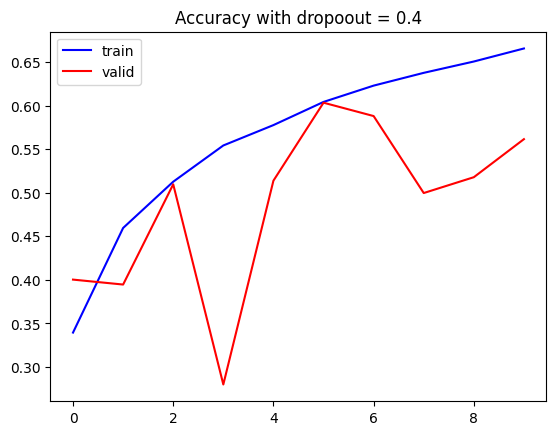

Test accuracy: 56.1%


In [ ]:
best_model_dropout40 = best_model_dropout40()

cost_train16, cost_valid16, acc_train16, acc_valid16 = train_eval(best_model_dropout40, 0.01, 10, 16, train_data, val_data)
plt.figure(2)
plt.plot(range(len(acc_train16)), acc_train16, "b-", label='train')
plt.plot(range(len(acc_valid16)), acc_valid16, "r-", label='valid')
plt.legend()
plt.title("Accuracy with dropoout = 0.4")
plt.show()
acc_test16 = evaluate(best_model_dropout40, val_data)

The accuracy dropped significantly with 40% of dropout, we can see that the performance of the accuracy is not homogeneous at all. With 40% of dropout, we preserve just 60% of activated neurons. This value might be to low to have an efficient model. We will keep the model with 30% of dropout, called ```deeper_cnnfilter64```.

#### **2. Early stopping**
In addition to dropout, we can stop the training when the validation stop to increase.

In [ ]:
def train_eval_early_stop(model, lr, nepochs, nbatch, training_data, validation_data, output=True):

    best_val_acc = 0
    patience = 5
    counter = 0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    cost_hist, cost_hist_test = [], []
    acc_hist,  acc_hist_test  = [], []

    cost_ce   = torch.nn.CrossEntropyLoss()

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader     = DataLoader(validation_data, batch_size=nbatch, shuffle=False)

    for epoch in range(nepochs):
        model.train()
        size, nbatches = len(training_loader.dataset), len(training_loader)
        cost, acc = 0.0, 0.0

        for X, Y in training_loader:
            X, Y = X.to(device), Y.to(device)   # GPU
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            loss.backward()

            with torch.no_grad():
                for param in model.parameters():
                    param -= lr * param.grad
                    param.grad.zero_()

        cost /= nbatches
        acc  /= size

        model.eval()
        size_test, nbatches_test = len(test_loader.dataset), len(test_loader)
        cost_test, acc_test = 0.0, 0.0

        with torch.no_grad():
            for X, Y in test_loader:
                X, Y = X.to(device), Y.to(device)
                pred       = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test  += (pred.argmax(dim=1) == Y).float().sum().item()

        cost_test /= nbatches_test
        acc_test  /= size_test

        if output:
            print("Epoch %i : %.4f, %.4f, %.4f, %.4f" % (epoch, cost, acc, cost_test, acc_test))

        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)

        if acc_test > best_val_acc:     # early stopping
            best_val_acc = acc_test
            torch.save(model.state_dict(), 'best_model.pth')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping à l'epoch {epoch}, meilleure val acc: {100*best_val_acc:.1f}%")
                break

    model.load_state_dict(torch.load('best_model.pth'))
    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

We can try the early stopping on the best previous model, the one with the dropout at 30%.

Epoch 0 : 1.9720, 0.3467, 1.6127, 0.4458
Epoch 1 : 1.5470, 0.4684, 1.5907, 0.4540
Epoch 2 : 1.3840, 0.5254, 4.9226, 0.2087
Epoch 3 : 1.2728, 0.5615, 1.2851, 0.5525
Epoch 4 : 1.1956, 0.5937, 1.5942, 0.5100
Epoch 5 : 1.1129, 0.6238, 1.2492, 0.5588
Epoch 6 : 1.0662, 0.6352, 1.3110, 0.5612
Epoch 7 : 1.0158, 0.6533, 1.3139, 0.5838
Epoch 8 : 0.9618, 0.6718, 2.5220, 0.3558
Epoch 9 : 0.9257, 0.6835, 1.3965, 0.5608


/tmp/ipykernel_7546/396358227.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


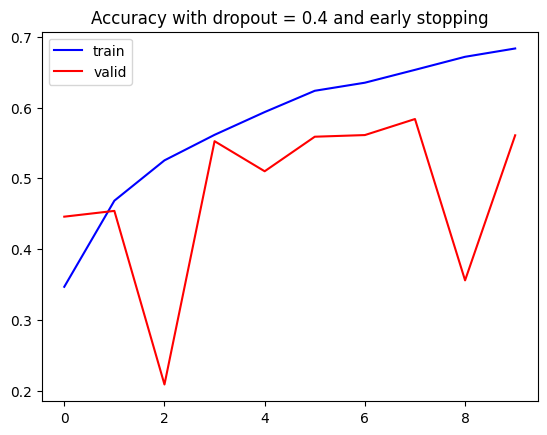

Test accuracy: 58.4%


In [ ]:
early_stop = deeper_cnnfilter64()
cost_train18, cost_valid18, acc_train18, acc_valid18 = train_eval_early_stop(early_stop, 0.01, 10, 16, train_data, val_data)
plt.figure(2)
plt.plot(range(len(acc_train18)), acc_train18, "b-", label='train')
plt.plot(range(len(acc_valid18)), acc_valid18, "r-", label='valid')
plt.legend()
plt.title("Accuracy with dropout = 0.4 and early stopping")
plt.show()
acc_test18 = evaluate(early_stop, val_data)

The accuracy is not that far behind but not better, we are goind to stick to a model without early stopping.

To improve the performance, a good pratice would be to have a full independant test dataset. Indeed, the validation data set is used during the training loop and for the test.
_____________

#### **Conclusion**
The best model is the one with a dropout of 30% without early stopping, with an accuracy of **62.5%**. It is the one we're going to keep for the rest of the Lab.

### **V. Optimization**

#### **1. Adam**
To optimize our models, we are going to add the Adam optimizer with weight decay = 1e-4 and lr = 1e-3 on the training process.


In [ ]:
def train_eval_adam(model, lr, nepochs, nbatch, training_data, validation_data, output=True):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU
    model = model.to(device)                                                 # GPU

    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)        # Adam
    cost_hist, cost_hist_test = [], []
    acc_hist,  acc_hist_test  = [], []
    cost_ce = torch.nn.CrossEntropyLoss()

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0

        for batch, (X, Y) in enumerate(training_loader):
            X, Y = X.to(device), Y.to(device)                               # GPU
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0

        with torch.no_grad():
            for X, Y in test_loader:
                X, Y = X.to(device), Y.to(device)                           # GPU
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test  += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        cost_test /= nbatches_test
        acc_test /= size_test

        if output:
            print("Epoch %i : %f, %f, %f, %f" % (epoch, cost, acc, cost_test, acc_test))

        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

Epoch 0 : 1.806810, 0.381792, 1.600477, 0.451333
Epoch 1 : 1.434977, 0.503083, 1.404545, 0.517167
Epoch 2 : 1.277472, 0.561000, 1.276168, 0.553167
Epoch 3 : 1.174672, 0.595958, 1.464675, 0.501000
Epoch 4 : 1.086586, 0.629125, 1.206083, 0.600833
Epoch 5 : 1.001031, 0.657792, 1.300410, 0.568000
Epoch 6 : 0.937924, 0.673375, 1.474268, 0.512833
Epoch 7 : 0.879584, 0.695042, 1.076550, 0.640167
Epoch 8 : 0.826207, 0.716708, 1.255863, 0.582000
Epoch 9 : 0.789139, 0.727042, 1.064779, 0.641500


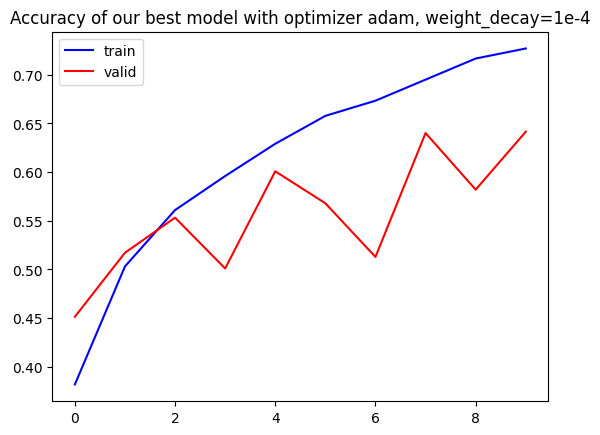

Test accuracy: 64.1%


In [ ]:
model_adam = deeper_cnnfilter64()
cost_train19, cost_valid19, acc_train19, acc_valid19 = train_eval_adam(model_adam, 0.01, 10, 16, train_data, val_data)
plt.figure()
plt.plot(range(len(acc_train19)), acc_train19, "b-", label='train')
plt.plot(range(len(acc_valid19)), acc_valid19, "r-", label='valid')
plt.legend()
plt.title("Accuracy of our best model with optimizer adam, weight_decay=1e-4")
plt.show()
acc_test19 = evaluate(model_adam, val_data)

The accuracy is better with the optimizer adam with usual values for its lr and its weight_decay.

#### **2. RMSprop**

In [ ]:
def train_eval_RMSprop(model, lr, nepochs, nbatch, training_data, validation_data, output=True):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU
    model = model.to(device)                                                 # GPU

    optimizer = torch.optim.RMSprop(model.parameters(),lr=1e-3,weight_decay=1e-4)     # RMSprop
    cost_hist, cost_hist_test = [], []
    acc_hist,  acc_hist_test  = [], []
    cost_ce = torch.nn.CrossEntropyLoss()

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0

        for batch, (X, Y) in enumerate(training_loader):
            X, Y = X.to(device), Y.to(device)                               # GPU
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0

        with torch.no_grad():
            for X, Y in test_loader:
                X, Y = X.to(device), Y.to(device)                           # GPU
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test  += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        cost_test /= nbatches_test
        acc_test /= size_test

        if output:
            print("Epoch %i : %f, %f, %f, %f" % (epoch, cost, acc, cost_test, acc_test))

        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

Epoch 0 : 2.000621, 0.341250, 1.627241, 0.433333
Epoch 1 : 1.486342, 0.486583, 1.672057, 0.442667
Epoch 2 : 1.304904, 0.555042, 1.435118, 0.506500
Epoch 3 : 1.180416, 0.595500, 1.769666, 0.454333
Epoch 4 : 1.096282, 0.625333, 1.269033, 0.568000
Epoch 5 : 1.026112, 0.648583, 1.266722, 0.584000
Epoch 6 : 0.964095, 0.672792, 1.508707, 0.537333
Epoch 7 : 0.911847, 0.687125, 1.209713, 0.600500
Epoch 8 : 0.853457, 0.708042, 1.323897, 0.586333
Epoch 9 : 0.815391, 0.719292, 2.103073, 0.416000


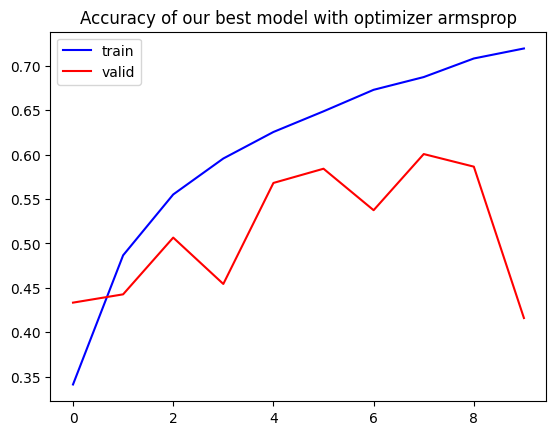

Test accuracy: 41.6%


In [ ]:
model_rms=deeper_cnnfilter64()
cost_train20, cost_valid20, acc_train20, acc_valid20 = train_eval_RMSprop(model_rms, 0.01, 10, 16, train_data, val_data)
plt.figure(2)
plt.plot(range(len(acc_train20)), acc_train20, "b-", label='train')
plt.plot(range(len(acc_valid20)), acc_valid20, "r-", label='valid')
plt.legend()
plt.title("Accuracy of our best model with optimizer rmsprop")
plt.show()
acc_test20 = evaluate(model_rms, val_data)

#### ***Conclusion***
The adam optimizer has here better performance. RMS might reach better performance with other hyperparameters.
_______________

### **VI. Optional objectives**
**1. Weight and biases**

From the begging of this pratical work, we used ```wandb``` to compare the differents training processes of our models, before selecting one for the tuning.

The next plots are the result from wandb for the first part, where :
- the <span style='color: blue;'>blue</span> curve represents the ```simple_cnn```
- the <span style='color: red;'>red</span> curve represents the ```deeper_cnn``` model
- the <span style='color: green;'>green</span> curve represents the ```more_deeper_cnn``` model
- and the <span style='color: purple;'>violet</span> curve represents the ```more_deeper_cnn_dropout``` model with 30% of dropout.

We can observes that the <span style='color: blue;'>simple_cnn</span> is too simple : its losses (val and train) are the highest and its accuracies (val and train) are the lowest. At the contrary, the other models have better losses and accuracies. However, they differ about the stability of their curves. The <span style='color: purple;'>more_deeper_cnn_dropout</span> is the model with a smoothest curves. Its accuracy is not the better but we prefered keeping a model with a stable learning process. In that way, we ensure that the results are reproductible.



We decide to analyze the training of the four first models of simple cnn and deeper cnn with ```wandb``` to choose wisely the model which we will keep for the following part of this pratical work. We didn't used ```wandb``` for the next part because this tool implies longer running time, and we assume that try to understand the utility of this tool on the first part was what's was expected for this lab.


**2. data augmentation**

To diversify our data set, we can apply data transforms as random cropping, horizontal clipping and color jittering. We add also normalization to our pictures.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6988237].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8208281].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Cl

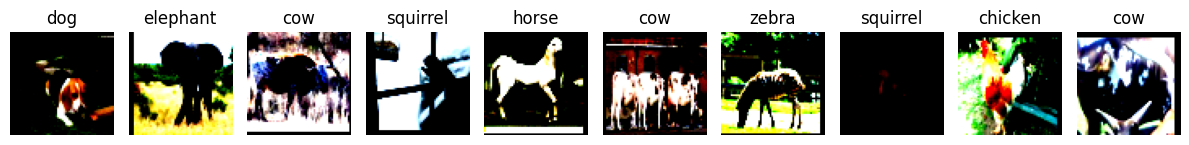

In [ ]:
train_transforms2 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


val_transforms2 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data2 = datasets.ImageFolder(
    root=f"{data_root}/train",
    transform=train_transforms2
)

val_data2 = datasets.ImageFolder(
    root=f"{data_root}/validate",
    transform=val_transforms2
)

train_loader2 = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader2   = DataLoader(val_data2,   batch_size=32, shuffle=False)

figure = plt.figure(figsize=(12, 12))
for i in range(10):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data2[sample_idx]
    figure.add_subplot(1, 10, 1+i)
    plt.title(train_data2.classes[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))     # (C,H,W) -> (H,W,C)

plt.tight_layout()
plt.show()

We can observe that some image are flipped, no longuer centered, or have changed in theirs colors. We can now train our best model on this new dataset and compare the accuracies.

Epoch 0 : 1.883762, 0.349375, 1.554981, 0.448500
Epoch 1 : 1.556582, 0.459708, 1.448163, 0.492167
Epoch 2 : 1.421783, 0.510792, 1.266414, 0.561333
Epoch 3 : 1.327062, 0.543542, 1.242072, 0.577167
Epoch 4 : 1.259497, 0.565500, 1.149673, 0.607000
Epoch 5 : 1.200081, 0.589333, 1.063374, 0.633500
Epoch 6 : 1.150060, 0.603083, 1.100134, 0.616500
Epoch 7 : 1.110132, 0.620625, 0.995474, 0.657500
Epoch 8 : 1.073105, 0.632500, 1.010242, 0.652000
Epoch 9 : 1.044131, 0.644417, 0.975561, 0.669500


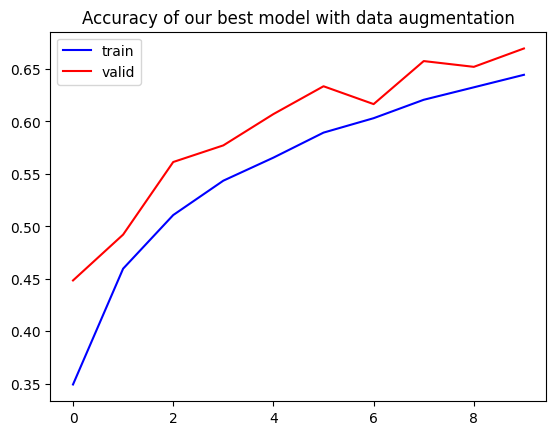

Test accuracy: 67.0%


In [ ]:
model_aug = deeper_cnnfilter64()
cost_train21, cost_valid21, acc_train21, acc_valid21 = train_eval_adam(model_aug, 0.01, 10, 16, train_data2, val_data2)
plt.figure()
plt.plot(range(len(acc_train21)), acc_train21, "b-", label='train')
plt.plot(range(len(acc_valid21)), acc_valid21, "r-", label='valid')
plt.legend()
plt.title("Accuracy of our best model with data augmentation")
plt.show()
acc_test21 = evaluate(model_aug, val_data2)

The data augmentation allows to artificially enrich our dataset by providing images with rotation, flip, color changes... With this technique, we reach an accuracy of **67%** with our best model and with the adam optimizer.

**3. ResNet and GoogleNet**

We will compare the values of the accuracies between our best model and new ones trained with ResNet and GoogleNet.

**a. ResNet**

We need to resize our pictures in the format demanded by ResNet : 224x224.

In [ ]:
from torchvision.models import resnet152, ResNet152_Weights

train_transforms3 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomCrop(224, padding=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms3 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data3 = datasets.ImageFolder(
    root=f"{data_root}/train",
    transform=train_transforms3
)
val_data3 = datasets.ImageFolder(
    root=f"{data_root}/validate",
    transform=val_transforms3
)

train_loader3 = DataLoader(train_data3, batch_size=32, shuffle=True)
val_loader3   = DataLoader(val_data3,   batch_size=32, shuffle=False)

num_classes = len(train_data3.classes)

weights = ResNet152_Weights.DEFAULT
model_resnet   = resnet152(weights=weights)
model_resnet.fc = torch.nn.Linear(model_resnet.fc.in_features, num_classes) # adapt head of resnet

Epoch 0 : 0.830712, 0.727958, 0.722870, 0.751833
Epoch 1 : 0.567019, 0.812458, 0.490201, 0.841667
Epoch 2 : 0.529986, 0.824250, 0.440234, 0.856500
Epoch 3 : 0.488973, 0.837583, 0.459903, 0.848167
Epoch 4 : 0.443696, 0.850417, 0.498301, 0.838667
Epoch 5 : 0.418903, 0.863083, 0.451886, 0.854667
Epoch 6 : 0.398840, 0.866167, 0.429988, 0.861333
Epoch 7 : 0.378025, 0.874125, 0.423036, 0.860333
Epoch 8 : 0.360963, 0.879417, 0.368158, 0.874000
Epoch 9 : 0.347349, 0.883958, 0.337523, 0.885833


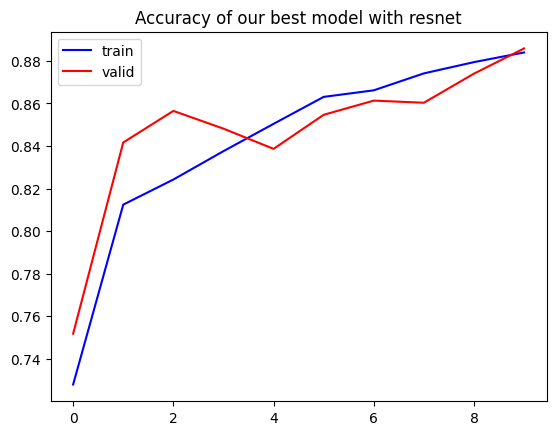

Test accuracy: 23.0%


In [ ]:
cost_train22, cost_valid22, acc_train22, acc_valid22  = train_eval_adam(model_resnet, lr, 10, 16, train_data3, val_data3)
plt.figure()
plt.plot(range(len(acc_train22)), acc_train22, "b-", label='train')
plt.plot(range(len(acc_valid22)), acc_valid22, "r-", label='valid')
plt.legend()
plt.title("Accuracy of our best model with resnet")
plt.show()
acc_test22 = evaluate(model_resnet, val_data)

The returned value of 23% is a mistake. Indeed, we must use ```val_data3``` with the function ```evaluate```.

In [ ]:
acc_test22 = evaluate(model_resnet, val_data3)

Test accuracy: 88.6%


**b. GoogleNet**

We decided to use GoogleNet to because this model can reach the performances of ResNet but with far fewer parameters. Its running time is much shorter.
We also have to use resized images with GoogleNet.

In [ ]:
from torchvision.models import googlenet, GoogLeNet_Weights

weights_googlenet = GoogLeNet_Weights.DEFAULT
model_googlenet = googlenet(weights=weights_googlenet)
model_googlenet.aux_logits = False
model_googlenet.aux1 = None
model_googlenet.aux2 = None
model_googlenet.fc = torch.nn.Linear(model_googlenet.fc.in_features, num_classes)

cost_train23, cost_valid23, acc_train23, acc_valid23  = train_eval_adam(model_googlenet, lr, 10, 16, train_data3, val_data3)


Epoch 0 : 0.790635, 0.739750, 0.547571, 0.812667
Epoch 1 : 0.553409, 0.817583, 0.413558, 0.857167
Epoch 2 : 0.488062, 0.838375, 0.539456, 0.816667
Epoch 3 : 0.451052, 0.851583, 0.417048, 0.862000
Epoch 4 : 0.426381, 0.858917, 0.366249, 0.878833
Epoch 5 : 0.399241, 0.868708, 0.389497, 0.872500
Epoch 6 : 0.380054, 0.875042, 0.484765, 0.840667
Epoch 7 : 0.361452, 0.880042, 0.339709, 0.888667
Epoch 8 : 0.341361, 0.887458, 0.389471, 0.871667
Epoch 9 : 0.334815, 0.892917, 0.362883, 0.876833


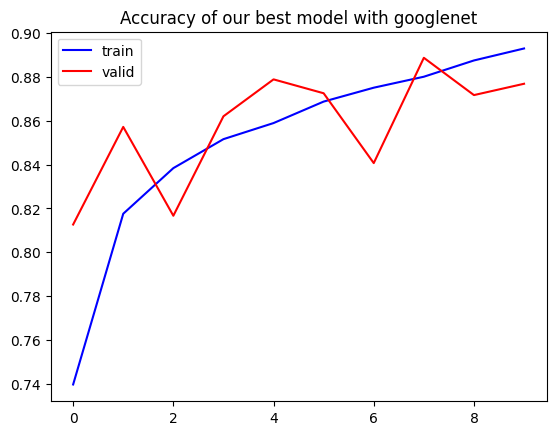

Test accuracy: 87.7%


In [ ]:
plt.figure()
plt.plot(range(len(acc_train23)), acc_train23, "b-", label='train')
plt.plot(range(len(acc_valid23)), acc_valid23, "r-", label='valid')
plt.legend()
plt.title("Accuracy of our best model with googlenet")
plt.show()
acc_test23 = evaluate(model_googlenet, val_data3)

ResNet and GoogleNet can reach an accuracy of **80%**. Theses two models are very powerful due to theirs high numbers of parameters and capabilities to generalize rules over the data set of images. Our best model is very simple compare too ResNet and GoogleNet : there is far fewer layers and parameters.
__________________________

### **Conclusion**

During this practical work, we tested 23 different models, from simple CNNs to powerful pretrained architectures, such as GoogLeNet. We demonstrated that hyperparameter tuning plays an important role in achieving good generalization. Regularization techniques such as weight decay and dropout, combined with optimizers, allowed us to improve model performance. Finally, standard techniques such as data augmentation helped reduce overfitting by "diversifying" the data set, while monitoring weights and biases provided valuable insight into the learning dynamics. Deeper CNN can reached higher performances, as GoogleNet and ResNet with appropriate regularization and optimizations techniques.